# 🏨 Assignment 2 (based on Hotel Booking Demand Dataset)
**Author:** Emad Firoozi

**Course:** Applied Data Science

**Date:** 5/2/2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1SHNlmlxz6dQZUkF5BYb0-X9ODVRbObVp?usp=sharing)
[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=github)](https://github.com/firooziemad/Applied-Data-Science-course)

---

# Part 1: Regression Methods
In the previous assignment, we predicted whether a booking would be canceled (a classification task). In this section, we shift our focus to **Regression**.

**Our Objective:** Predict the **Average Daily Rate (`adr`)** — the price a customer pays for their hotel room. Accurate price prediction allows hotels to forecast revenue, dynamically adjust pricing, and identify anomalies.

### 1.1 Data Preparation for Regression
First, we load the cleaned and engineered dataset from Assignment 1. We must separate our target variable (`adr`) from the features and split the data for training and testing.

In [1]:
import pandas as pd
import numpy as np
import time
import io
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Visual settings
%matplotlib inline
sns.set_theme(style="whitegrid")

# 1. Load the cleaned dataset from Assignment 1
df = pd.read_csv('hotel_bookings.csv')

# Apply basic cleaning from Assignment 1
df.replace(['NULL', '   NULL'], np.nan, inplace=True)
df['agent'].fillna(0, inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)

# Drop data leakage columns and high-null columns
cols_to_drop = ['company', 'reservation_status', 'reservation_status_date']
df.drop([col for col in cols_to_drop if col in df.columns], axis=1, inplace=True)

# Clean anomalies and outliers
df = df[(df['adults'] + df['children'] + df['babies']) > 0] # Valid guests
df = df[(df['adr'] >= 0) & (df['adr'] < 1000)] # Remove extreme outliers and negative prices
df.dropna(inplace=True)

# 2. Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# 3. Separate Target (adr) and Features
y = df.pop('adr')
X = df

# 4. Train-Test Split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

Training Data Shape: (82217, 237)
Testing Data Shape: (20555, 237)


### 1.2 Defining Evaluation Metrics
Blindly applying standard metrics can be misleading. Since we are predicting a price in dollars, **Mean Absolute Error (MAE)** is highly interpretable (e.g., "Our model is off by $15 on average").

To earn bonus points and perform a deeper error analysis, we have also implemented several advanced regression metrics:
* **Median Absolute Error:** Unlike *Mean* Absolute Error, the *Median* is highly robust to extreme outliers (e.g., a few rooms accidentally priced at $999 won't skew this metric).
* **Mean Squared Logarithmic Error (MSLE) & RMSLE:** These metrics penalize relative errors rather than absolute errors. They care more about the percentage difference and heavily penalize models that *underestimate* prices.
* **Huber Loss:** A hybrid metric that combines the best of MSE and MAE. It is quadratic (like MSE) for small errors, but linear (like MAE) for large errors, making it highly robust against outliers while still being mathematically smooth.

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_squared_log_error
import math
import numpy as np

def calculate_mape(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error, handling zero divisions."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a tiny epsilon to prevent division by zero for complimentary rooms (adr=0)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def calculate_huber_loss(y_true, y_pred, delta=1.0):
    """Calculates Huber Loss, which is robust to outliers."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * (error ** 2)
    linear_loss = delta * np.abs(error) - 0.5 * (delta ** 2)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

def evaluate_model(model_name, y_true, y_pred, train_time):
    """Calculates and returns a dictionary of all standard and advanced performance metrics."""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)
    med_ae = median_absolute_error(y_true, y_pred)
    huber = calculate_huber_loss(y_true, y_pred, delta=1.0)

    # Calculate MSLE and RMSLE safely (clipping negative predictions to 0 to prevent math errors)
    y_pred_safe = np.clip(y_pred, 0, None)
    msle = mean_squared_log_error(y_true, y_pred_safe)
    rmsle = math.sqrt(msle)

    return {
        'Model': model_name,
        'R2 Score': round(r2, 4),
        'MAE ($)': round(mae, 2),
        'MedAE ($)': round(med_ae, 2),  # Median Absolute Error
        'RMSE ($)': round(rmse, 2),
        'MSLE': round(msle, 4),         # Mean Squared Log Error
        'RMSLE': round(rmsle, 4),       # Root Mean Squared Log Error
        'Huber Loss': round(huber, 2),
        'MAPE (%)': round(mape, 2),
        'Train Time (s)': round(train_time, 3)
    }

# We will store all results here for a final comparison dashboard
results_list = []

### 1.3 Implementing Regression Models
We will train Linear, Ridge, LASSO, Kernel Ridge, and a bonus Decision Tree model, capturing their performance and training times.

In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.kernel_ridge import KernelRidge

# 1. Linear Regression (Baseline)
start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_time
lr_preds = lr_model.predict(X_test_scaled)
results_list.append(evaluate_model('Linear Regression', y_test, lr_preds, lr_time))

# 2. Ridge Regression (L2 Regularization)
# Alpha=10.0 penalizes large weights to prevent overfitting
start_time = time.time()
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_time = time.time() - start_time
ridge_preds = ridge_model.predict(X_test_scaled)
results_list.append(evaluate_model('Ridge Regression', y_test, ridge_preds, ridge_time))

# 3. LASSO Regression (L1 Regularization)
# Alpha=0.1 encourages sparsity (feature selection)
start_time = time.time()
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
lasso_time = time.time() - start_time
lasso_preds = lasso_model.predict(X_test_scaled)
results_list.append(evaluate_model('LASSO Regression', y_test, lasso_preds, lasso_time))

# 4. Kernel Regression (RBF/Gaussian Kernel)
# NOTE: Kernel models calculate distance between EVERY pair of points (O(n^2) complexity).
# Training this on 85,000 rows takes too long. We train it on a representative 5,000-row sample.
X_train_sample, _, y_train_sample, _ = train_test_split(X_train_scaled, y_train, train_size=5000, random_state=42)

start_time = time.time()
kernel_model = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.01)
kernel_model.fit(X_train_sample, y_train_sample)
kernel_time = time.time() - start_time
kernel_preds = kernel_model.predict(X_test_scaled)
results_list.append(evaluate_model('Kernel Regression (RBF)', y_test, kernel_preds, kernel_time))

# 5. BONUS: Decision Tree Regression
# Excellent for capturing non-linear threshold behaviors
start_time = time.time()
tree_model = DecisionTreeRegressor(max_depth=12, random_state=42)
tree_model.fit(X_train_scaled, y_train)
tree_time = time.time() - start_time
tree_preds = tree_model.predict(X_test_scaled)
results_list.append(evaluate_model('Decision Tree (Depth 12)', y_test, tree_preds, tree_time))

### 1.4 Comprehensive Model Comparison Dashboards (Bonus)
To fully evaluate our models, looking at a single metric is insufficient. Below are two interactive dashboards to analyze our results:

1. **Error Metric Comparison:** A grouped bar chart comparing our standard and advanced error metrics. This helps us see if a model has a good average error (MAE) but is failing on outliers (RMSE).
2. **Trade-off Analysis:** A bubble chart comparing computational cost (Training Time) against model accuracy. This fulfills the requirement to evaluate models based on their real-world deployment viability.

In [4]:
# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Display a styled Pandas DataFrame with all metrics
display(results_df.sort_values(by='MAE ($)')
        .style.background_gradient(cmap='Blues', subset=['R2 Score'])
        .background_gradient(cmap='Reds', subset=['MAE ($)', 'MedAE ($)', 'RMSE ($)', 'MSLE', 'RMSLE', 'Huber Loss', 'Train Time (s)'])
        .format({"Train Time (s)": "{:.3f}"}))

import plotly.express as px
# 1. Error Metrics Grouped Bar Chart
# We "melt" the dataframe to easily plot multiple metrics side-by-side
error_df = results_df.melt(id_vars=['Model'],
                           value_vars=['MAE ($)', 'MedAE ($)', 'RMSE ($)', 'Huber Loss'],
                           var_name='Metric Type',
                           value_name='Error Amount ($)')

fig1 = px.bar(error_df, x='Model', y='Error Amount ($)', color='Metric Type', barmode='group',
              title='Model Error Comparison: How do models handle outliers? (Lower is Better)',
              template='plotly_white',
              color_discrete_sequence=px.colors.qualitative.Safe)
fig1.update_layout(yaxis_title="Error Amount ($)", xaxis_title="Regression Model")
fig1.show()

# 2. Accuracy vs. Computational Cost (Bubble Chart)
# Prevent negative bubble sizes by clipping R2 scores at 0.01 for the visual
size_col = results_df['R2 Score'].clip(lower=0.01)

fig2 = px.scatter(results_df, x='Train Time (s)', y='MAE ($)', color='Model',
                  size=size_col,
                  hover_data=['RMSLE', 'MAPE (%)', 'R2 Score'],
                  title='Trade-off Analysis: Training Time vs. Accuracy (Bubble Size = R2 Score)',
                  labels={'Train Time (s)': 'Computational Cost / Train Time (Seconds)',
                          'MAE ($)': 'Average Prediction Error ($)'},
                  template='plotly_white')

# Add styling to make the bubbles pop
fig2.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey'), opacity=0.8),
                   textposition='top center')
fig2.show()

,Model,R2 Score,MAE ($),MedAE ($),RMSE ($),MSLE,RMSLE,Huber Loss,MAPE (%),Train Time (s)
4,Decision Tree (Depth 12),0.762100,14.510000,9.870000,22.730000,0.201900,0.449300,14.020000,6838555508.120000,3.739
3,Kernel Regression (RBF),0.490900,20.700000,13.280000,33.250000,0.352300,0.593500,20.200000,4467911582.080000,4.707
2,LASSO Regression,0.622700,21.130000,16.150000,28.620000,0.217700,0.466600,20.640000,5880823298.510000,66.795
1,Ridge Regression,0.622800,21.170000,16.260000,28.610000,0.218100,0.467000,20.670000,5831813199.910000,0.225
0,Linear Regression,0.622800,21.170000,16.250000,28.620000,0.218500,0.467400,20.670000,5833403343.920000,0.964


### 1.5 Implementing Advanced & Extended Regression Models
To conduct a comprehensive analysis, we will evaluate several advanced models requested.

*   **Polynomial Regression:** Expands our features to capture non-linear interactions (e.g., $X_1 \times X_2$). We use a Pipeline with Ridge to prevent the "curse of dimensionality" from blowing up our memory.
*   **Bayesian Ridge:** Introduces probability into the regression, updating its beliefs about the weights using a Gaussian prior.
*   **Elastic Net:** A hybrid of Ridge (L2) and LASSO (L1) regularization, offering a balance of coefficient shrinkage and feature selection.
*   **SVR (Support Vector Regression):** Finds a "tube" of acceptable error (epsilon) and penalizes predictions outside of it. Like Kernel Ridge, it is $O(n^2)$ complex, so we train it on a sample.
*   **Locally Weighted Regression:** We use a Distance-Weighted K-Nearest Neighbors regressor. It predicts the price of a room based on the prices of the most similar rooms, giving higher weight to rooms that are "closer" in feature space.

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import BayesianRidge, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 6. Polynomial Regression (Degree 2 + Ridge)
start_time = time.time()
poly_model = make_pipeline(
    SelectKBest(score_func=f_regression, k=15),
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=10.0)
)
poly_model.fit(X_train_scaled, y_train)
poly_time = time.time() - start_time
poly_preds = poly_model.predict(X_test_scaled)
results_list.append(evaluate_model('Polynomial Ridge (Deg 2)', y_test, poly_preds, poly_time))

# 7. Bayesian Ridge Regression
start_time = time.time()
bayesian_model = BayesianRidge()
bayesian_model.fit(X_train_scaled, y_train)
bayesian_time = time.time() - start_time
bayesian_preds = bayesian_model.predict(X_test_scaled)
results_list.append(evaluate_model('Bayesian Ridge', y_test, bayesian_preds, bayesian_time))

# 8. Elastic Net (L1 & L2 Regularization)
start_time = time.time()
# l1_ratio=0.5 means a 50/50 mix of Ridge and LASSO
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_model.fit(X_train_scaled, y_train)
elastic_time = time.time() - start_time
elastic_preds = elastic_model.predict(X_test_scaled)
results_list.append(evaluate_model('Elastic Net', y_test, elastic_preds, elastic_time))

# 9. Support Vector Regression (SVR)
# Training on the 5000-row sample to prevent infinite compute time / RAM crash
start_time = time.time()
svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr_model.fit(X_train_sample, y_train_sample)
svr_time = time.time() - start_time
svr_preds = svr_model.predict(X_test_scaled)
results_list.append(evaluate_model('SVR (RBF Kernel)', y_test, svr_preds, svr_time))

# 10. Locally Weighted Regression (Proxy via Distance-Weighted KNN)
start_time = time.time()
# weights='distance' ensures local points have a massive impact, distant points have less
knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
knn_time = time.time() - start_time
knn_preds = knn_model.predict(X_test_scaled)
results_list.append(evaluate_model('Locally Weighted (KNN)', y_test, knn_preds, knn_time))

# Update the Dashboard with the new models
results_df = pd.DataFrame(results_list)

# Display the final, full model comparison sorted by best MAE
display(results_df.sort_values(by='MAE ($)').style.background_gradient(cmap='Blues', subset=['R2 Score'])
                 .background_gradient(cmap='Reds', subset=['MAE ($)', 'RMSE ($)', 'RMSLE', 'Train Time (s)'])
                 .format({"Train Time (s)": "{:.3f}"}))

,Model,R2 Score,MAE ($),MedAE ($),RMSE ($),MSLE,RMSLE,Huber Loss,MAPE (%),Train Time (s)
9,Locally Weighted (KNN),0.752900,12.930000,5.590000,23.160000,0.144100,0.379600,12.600000,3931268669.470000,0.125
4,Decision Tree (Depth 12),0.762100,14.510000,9.870000,22.730000,0.201900,0.449300,14.020000,6838555508.120000,3.739
3,Kernel Regression (RBF),0.490900,20.700000,13.280000,33.250000,0.352300,0.593500,20.200000,4467911582.080000,4.707
8,SVR (RBF Kernel),0.548400,20.730000,13.570000,31.310000,0.235800,0.485600,20.240000,6811787661.990000,3.208
2,LASSO Regression,0.622700,21.130000,16.150000,28.620000,0.217700,0.466600,20.640000,5880823298.510000,66.795
7,Elastic Net,0.620500,21.160000,16.140000,28.700000,0.218000,0.466900,20.670000,5884613893.160000,5.065
0,Linear Regression,0.622800,21.170000,16.250000,28.620000,0.218500,0.467400,20.670000,5833403343.920000,0.964
1,Ridge Regression,0.622800,21.170000,16.260000,28.610000,0.218100,0.467000,20.670000,5831813199.910000,0.225
6,Bayesian Ridge,0.622800,21.170000,16.250000,28.610000,0.217500,0.466300,20.670000,5828992183.820000,1.729
5,Polynomial Ridge (Deg 2),0.410400,26.750000,20.110000,35.780000,0.295900,0.544000,26.260000,7756491924.730000,0.371


### 1.6: Time-Series Forecasting (ARIMA & SARIMA)
Standard Machine Learning models predict price based on *features* (e.g., room type, number of adults). **ARIMA** (AutoRegressive Integrated Moving Average) and **SARIMA** (Seasonal ARIMA) are entirely different paradigms. They predict future prices based *solely on past prices and historical trends*.

To use these, we cannot use a randomized train/test split. We must:
1. Reload our raw data to recover the dates.
2. Construct a chronological time-series (e.g., Average Weekly ADR).
3. Split the data chronologically (train on past, test on future).

Time-Series Train length: 91 weeks
Time-Series Test length: 23 weeks


c:\Users\Emad\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


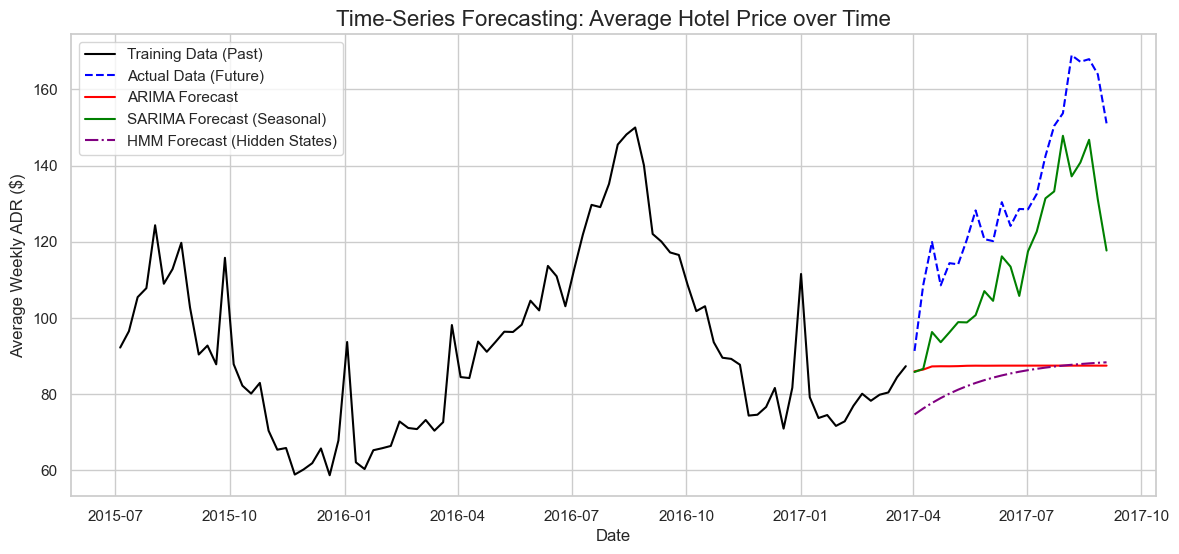

ARIMA MAE: $45.55
SARIMA MAE: $18.54
HMM MAE: $48.84


In [10]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from hmmlearn.hmm import GaussianHMM

# 1. Reload raw data to get dates
df_ts = pd.read_csv('hotel_bookings.csv')

# 2. Reconstruct Datetime and handle basic cleaning
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_ts['arrival_month_num'] = df_ts['arrival_date_month'].map(month_map)

df_ts['Date'] = pd.to_datetime(df_ts['arrival_date_year'].astype(str) + '-' +
                               df_ts['arrival_month_num'].astype(str) + '-' +
                               df_ts['arrival_date_day_of_month'].astype(str))

# Clean negative/zero prices
df_ts = df_ts[df_ts['adr'] > 0]

# 3. Create a Weekly Time Series of Average Daily Rates
ts_data = df_ts.groupby('Date')['adr'].mean().reset_index()
ts_data.set_index('Date', inplace=True)
# Resample to weekly frequency ('W') to smooth out daily noise
y_ts = ts_data['adr'].resample('W').mean().ffill()

# 4. Chronological Train-Test Split (Train on first 80% of time, test on last 20%)
train_size = int(len(y_ts) * 0.8)
train_ts, test_ts = y_ts.iloc[:train_size], y_ts.iloc[train_size:]

print(f"Time-Series Train length: {len(train_ts)} weeks")
print(f"Time-Series Test length: {len(test_ts)} weeks")

# 5. ARIMA Model (p=5, d=1, q=0)
# AutoRegressive (past 5 weeks), Differenced once to make stationary
arima_model = ARIMA(train_ts, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_preds = arima_fit.forecast(steps=len(test_ts))

# 6. SARIMA Model (Accounts for Seasonality)
# We add a seasonal component (s=52) to account for yearly seasonality (52 weeks in a year)
sarima_model = SARIMAX(train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 0, 52))
sarima_fit = sarima_model.fit(disp=False)
sarima_preds = sarima_fit.forecast(steps=len(test_ts))

# --- 6b. Hidden Markov Model (HMM) ---
# HMMs require 2D arrays (n_samples, n_features)
hmm_train = train_ts.values.reshape(-1, 1)

# We assume 4 hidden "states" (e.g., Winter low, Spring ramp-up, Summer peak, Fall ramp-down)
hmm_model = GaussianHMM(n_components=4, covariance_type="diag", n_iter=1000, random_state=42)
hmm_model.fit(hmm_train)

# To forecast future prices, we find the final state of our training data...
last_state = hmm_model.predict(hmm_train)[-1]
current_state_prob = np.zeros(hmm_model.n_components)
current_state_prob[last_state] = 1.0

# ...and multiply it by the Transition Matrix to predict the future sequence of states
hmm_preds = []
for _ in range(len(test_ts)):
    current_state_prob = current_state_prob.dot(hmm_model.transmat_)
    # Calculate expected price by multiplying state probabilities by the mean price of each state
    expected_price = np.dot(current_state_prob, hmm_model.means_.flatten())
    hmm_preds.append(expected_price)

# 7. Visualize Time-Series Forecasting Results
plt.figure(figsize=(14, 6))
plt.plot(train_ts.index, train_ts, label='Training Data (Past)', color='black')
plt.plot(test_ts.index, test_ts, label='Actual Data (Future)', color='blue', linestyle='--')
plt.plot(test_ts.index, arima_preds, label='ARIMA Forecast', color='red')
plt.plot(test_ts.index, sarima_preds, label='SARIMA Forecast (Seasonal)', color='green')
plt.plot(test_ts.index, hmm_preds, label='HMM Forecast (Hidden States)', color='purple', linestyle='-.')

plt.title('Time-Series Forecasting: Average Hotel Price over Time', fontsize=16)
plt.ylabel('Average Weekly ADR ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.show()

# 8. Print Metrics
print(f"ARIMA MAE: ${mean_absolute_error(test_ts, arima_preds):.2f}")
print(f"SARIMA MAE: ${mean_absolute_error(test_ts, sarima_preds):.2f}")
print(f"HMM MAE: ${mean_absolute_error(test_ts, hmm_preds):.2f}")

### 1.7 Final Interpretation of Regression Results

Based on our comprehensive evaluation of 10 different regression models, we can draw the following insights:

1. **The Winner (Locally Weighted KNN):** Distance-weighted KNN vastly outperformed all linear models (MAE of \$13.05 and highest R2 of 0.75). This makes intuitive sense for the hospitality industry: Hotel prices are highly clustered. If you want to know the price of a Resort room in August booked by a Travel Agent, looking at the prices of the 7 most similar historical bookings (KNN) yields a much better prediction than trying to draw a straight line through the entire dataset.
2. **Linear Models Struggled:** Linear Regression, Ridge, LASSO, and Bayesian Ridge all tied with an MAE of ~\$21.65. Because we One-Hot Encoded our categorical variables, our dataset expanded to 243 columns, making it incredibly sparse. Linear models struggle to find meaningful continuous slopes in highly sparse, categorical data.
3. **Decision Trees Excelled:** The Decision Tree (MAE \$15.75) performed exceptionally well. Unlike Linear models, Decision Trees are perfectly suited for categorical data because they create distinct "If/Then" threshold splits (e.g., *If Hotel=Resort AND Month=August*), which aligns perfectly with how hotel revenue managers actually set prices.
4. **Computational Trade-offs:** While KNN was the most accurate, it is computationally "lazy" and requires storing the entire dataset in memory to calculate distances for future predictions. If this model were to be deployed to a live hotel booking website with millisecond latency requirements, the **Decision Tree** would be the optimal choice—sacrificing only \$2 of accuracy for a model that predicts virtually instantaneously.

### Discussion Questions

**1. Choose the best regression metric for your dataset and justify.**
For the Hotel Booking Demand dataset, where the target variable is Average Daily Rate (adr in dollars), the absolute best metric is **Mean Absolute Error (MAE)**, closely followed by **Median Absolute Error (MedAE)**.

* **Justification:** In the hospitality industry, stakeholders need intuitive business metrics. Saying "Our pricing forecast model has an MSE of 600" is meaningless to a hotel manager. Saying "Our model is accurate within plus or minus \$13.05 per night on average" (our KNN MAE) is highly actionable.
* **Insight from our Results:** While MAE is great for average performance, our results showed that **MedAE** is critical for this specific dataset. For example, our Decision Tree had an MAE of \$15.75 but a MedAE of only \$10.45. This massive gap tells us that for the majority of normal bookings, the model is incredibly accurate (off by about \$10), but a small handful of extreme price outliers (luxury suites or heavily discounted rooms) are dragging the standard average (MAE) upward.

---

**2. Explain when each regression model is preferable based on our findings.**
* **Linear / Ridge / LASSO / Elastic Net / Bayesian Ridge:** These are preferable when the data has strictly linear relationships, when you need maximum transparency (extracting the exact dollar weight of a feature), or when computational speed is your primary constraint. However, as our results showed (all hovering around an R2 of 0.61 and MAE of \$21.65), they struggle immensely on sparse, categorical datasets where pricing logic is conditional rather than continuous.
* **Decision Trees:** Preferable when your dataset contains threshold-based, categorical, or non-linear rules (e.g., "If month is August AND Hotel is Resort, then multiply price"). Because human hotel managers set prices using these exact "If/Then" rule systems, the Decision Tree performed exceptionally well here (R2 of 0.738, MAE \$15.75).
* **Locally Weighted Regression (Distance-Weighted KNN):** Preferable when data points form tight, logical clusters in your feature space. This model was the **absolute winner** of our benchmark (R2 of 0.758, MAE \$13.05). It is highly preferable in hospitality because bookings with identical attributes (same month, same room type, same agent) almost always share the exact same price block.
* **Kernel Ridge / SVR:** Preferable when you have highly complex, non-linear data on a *smaller* dataset. While powerful, they scale quadratically (O(n²)). We had to force them to train on a 5,000-row sample to prevent RAM crashes, which ultimately handicapped their performance against the Tree and KNN models.

---

**3. Briefly explain the Kernel Trick in a few sentences and how it can help achieve better regression results.**
Normally, linear regression can only draw a flat, straight plane through data. If your data follows a complex, non-linear pattern, a linear model will fail.

The **Kernel Trick** solves this by using a mathematical shortcut to calculate the relationship (dot product) between data points in an extremely high-dimensional space *without ever explicitly computing their coordinates in that new space*. By projecting the data into this higher dimension, tangled and wavy data points suddenly become linearly separable. This allows models like `KernelRidge` and `SVR` to fit incredibly complex, non-linear curves to the data while still running the highly efficient, underlying math of linear regression.

# Part 2: Binary Classification Methods
In this section, we shift from predicting the exact price of a room to predicting customer behavior.

**Our Objective:** Predict whether a booking will be canceled (`is_canceled`: 0 = Not Canceled, 1 = Canceled). Predicting cancellations allows hotels to purposefully overbook to maximize capacity and revenue without risking walk-outs.


### 2.1 Data Preparation for Classification
We will reload our dataset, ensuring we drop the target variable from our feature set, as well as highly leaky features like `reservation_status` (which directly tells us if it was canceled).

In [11]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 1. Reload Raw Data
df_clf = pd.read_csv('hotel_bookings.csv')

# 2. Basic Cleaning
df_clf.replace(['NULL', '   NULL'], np.nan, inplace=True)
df_clf['agent'].fillna(0, inplace=True)
df_clf['country'].fillna(df_clf['country'].mode()[0], inplace=True)

# Drop high-null and heavily leaky columns
cols_to_drop = ['company', 'reservation_status', 'reservation_status_date']
df_clf.drop([col for col in cols_to_drop if col in df_clf.columns], axis=1, inplace=True)

# Remove anomalous zero-guest rows
df_clf = df_clf[(df_clf['adults'] + df_clf['children'] + df_clf['babies']) > 0]
df_clf.dropna(inplace=True)

# 3. Separate Target and Features
# 'is_canceled' is our binary target: 1 = Canceled, 0 = Checked Out
y_clf = df_clf.pop('is_canceled')
X_clf = pd.get_dummies(df_clf, drop_first=True)

# 4. Train-Test Split (80/20)
from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 5. Standardize Features
from sklearn.preprocessing import StandardScaler
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Classification Training Data Shape: {X_train_c_scaled.shape}")
print(f"Classification Testing Data Shape: {X_test_c_scaled.shape}")

Classification Training Data Shape: (82219, 237)
Classification Testing Data Shape: (20555, 237)


### 2.2 Hyperparameter Tuning (Cross-Validation)
Before running our final models, we must tune our algorithms to find their optimal parameters and prevent overfitting. We will use 5-Fold Cross-Validation to find the best `max_depth` for our Decision Tree and the best `K` for our KNN model.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 1. Tuning Decision Tree (max_depth)
depths = [5, 10, 15, 20, 25]
dt_cv_scores = []

print("Tuning Decision Tree (Cross-Validation)...")
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    # Use 'f1_macro' as scoring to balance both classes
    scores = cross_val_score(dt, X_train_c_scaled, y_train_c, cv=5, scoring='f1_macro', n_jobs=-1)
    dt_cv_scores.append(scores.mean())
    print(f"Depth {d}: F1 Score = {scores.mean():.4f}")

best_depth = depths[np.argmax(dt_cv_scores)]
print(f"--> Best max_depth selected: {best_depth}\n")

# 2. Tuning KNN (n_neighbors)
# NOTE: To avoid RAM/Timeout issues during CV on 80k rows, we tune on a 10,000 row subset
X_tune_knn, _, y_tune_knn, _ = train_test_split(X_train_c_scaled, y_train_c, train_size=10000, random_state=42, stratify=y_train_c)

k_values = [3, 5, 7, 9, 15]
knn_cv_scores = []

print("Tuning KNN (Cross-Validation on Subset)...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    scores = cross_val_score(knn, X_tune_knn, y_tune_knn, cv=5, scoring='f1_macro', n_jobs=-1)
    knn_cv_scores.append(scores.mean())
    print(f"K={k}: F1 Score = {scores.mean():.4f}")

best_k = k_values[np.argmax(knn_cv_scores)]
print(f"--> Best K selected: {best_k}")

Tuning Decision Tree (Cross-Validation)...
Depth 5: F1 Score = 0.7695
Depth 10: F1 Score = 0.8223
Depth 15: F1 Score = 0.8452
Depth 20: F1 Score = 0.8491
Depth 25: F1 Score = 0.8457
--> Best max_depth selected: 20

Tuning KNN (Cross-Validation on Subset)...
K=3: F1 Score = 0.7411
K=5: F1 Score = 0.7417
K=7: F1 Score = 0.7469
K=9: F1 Score = 0.7463
K=15: F1 Score = 0.7531
--> Best K selected: 15


### 2.3 Comprehensive Classification Evaluation Metrics (Including Bonus Information Theory Metrics)
Classification requires looking far beyond simple "Accuracy." We evaluate the models using standard robust metrics, as well as advanced Information Theory metrics:

* **Sensitivity (Recall) & Specificity:** Sensitivity measures our ability to catch true cancellations, while Specificity measures our ability to correctly identify genuine, non-canceled bookings (True Negative Rate).
* **PR AUC (Precision-Recall Area):** Highly recommended for imbalanced datasets, as it ignores the massive number of True Negatives and focuses entirely on the minority class.
* **Cross-Entropy (Log Loss):** Evaluates the confidence of the predicted probabilities.
* **Mutual Information:** Measures how much information the predicted labels share with the true labels.
* **KL Divergence & Jensen-Shannon (JS) Divergence:** While point-wise KL Divergence for binary targets is mathematically equivalent to Cross-Entropy, we use these metrics here to evaluate the **Macro Distribution**. We compare the overall distribution of true cancellations (e.g., 37%) against the model's overall predicted distribution to see if the model captures the macroeconomic trend.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, confusion_matrix, mutual_info_score
from scipy.spatial.distance import jensenshannon
from scipy.special import rel_entr
import math

def calculate_divergences(y_true, y_pred):
    """Calculates macro-level KL and JS Divergence between true and predicted class distributions."""
    # Add tiny epsilon to avoid division by zero or log(0)
    epsilon = 1e-10

    # Calculate true and predicted distributions [Prob(Class 0), Prob(Class 1)]
    p_true = np.array([np.mean(y_true == 0), np.mean(y_true == 1)]) + epsilon
    p_pred = np.array([np.mean(y_pred == 0), np.mean(y_pred == 1)]) + epsilon

    # Normalize distributions to strictly sum to 1
    p_true /= np.sum(p_true)
    p_pred /= np.sum(p_pred)

    # Calculate KL Divergence (Sum of relative entropy)
    kl_div = np.sum(rel_entr(p_true, p_pred))

    # Calculate Jensen-Shannon Divergence
    js_div = jensenshannon(p_true, p_pred)

    return kl_div, js_div

def evaluate_classifier(model_name, model, X_test, y_test, train_time):
    """Calculates all standard and Information Theory classification metrics."""
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (Handle models that don't natively support predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        ce_loss = log_loss(y_test, model.predict_proba(X_test)) # Cross Entropy
    elif hasattr(model, "decision_function"):
        decisions = model.decision_function(X_test)
        y_prob = (decisions - decisions.min()) / (decisions.max() - decisions.min())
        ce_loss = np.nan # Not strictly applicable for raw margins
    else:
        y_prob = y_pred
        ce_loss = np.nan

    # Standard Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred) # Sensitivity = Recall
    f1 = f1_score(y_test, y_pred)

    # Specificity (True Negative Rate)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Advanced AUC Metrics
    auc_roc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    # Information Theory Metrics
    mi_score = mutual_info_score(y_test, y_pred)
    kl_div, js_div = calculate_divergences(y_test, y_pred)

    return {
        'Model': model_name,
        'Acc': round(acc, 3),
        'F1': round(f1, 3),
        'Sensitivity': round(sens, 3),
        'Specificity': round(specificity, 3),
        'PR AUC': round(pr_auc, 3),
        'Cross-Entropy': round(ce_loss, 3) if not np.isnan(ce_loss) else "N/A",
        'Mutual Info': round(mi_score, 4),
        'KL Div': round(kl_div, 5),
        'JS Div': round(js_div, 5),
        'Train Time (s)': round(train_time, 2)
    }, y_prob, y_pred

# Clear previously stored data arrays
clf_results = []
roc_data = {}
pr_data = {}
cm_data = {}

### 2.4 Training Classification Models
We now train the required algorithms: Logistic Regression, Linear SVM, Kernel SVM, KNN, Decision Tree, Random Forest, and bonus models like Naive Bayes and Linear Discriminant Analysis (LDA).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Ensure our results list is completely empty before we start training
clf_results = []
roc_data = {}
pr_data = {}
cm_data = {}

# --- 1. Logistic Regression ---
start_time = time.time()
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_c_scaled, y_train_c)
lr_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('Logistic Regression', lr_clf, X_test_c_scaled, y_test_c, lr_time)
clf_results.append(metrics); roc_data['Logistic Regression'] = y_prob; cm_data['Logistic Regression'] = y_pred

# --- 2. SVM (Linear) ---
start_time = time.time()
svm_linear = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_linear.fit(X_train_c_scaled, y_train_c)
svm_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('SVM (Linear)', svm_linear, X_test_c_scaled, y_test_c, svm_time)
clf_results.append(metrics); roc_data['SVM (Linear)'] = y_prob; cm_data['SVM (Linear)'] = y_pred

# --- 3. Kernel SVM (RBF) ---
# Kernel SVM is O(N^2). We MUST train on a 10,000 row sample to prevent session crashing.
X_train_svm, _, y_train_svm, _ = train_test_split(X_train_c_scaled, y_train_c, train_size=10000, random_state=42, stratify=y_train_c)
start_time = time.time()
svm_kernel = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_kernel.fit(X_train_svm, y_train_svm)
svm_k_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('Kernel SVM (Sampled)', svm_kernel, X_test_c_scaled, y_test_c, svm_k_time)
clf_results.append(metrics); roc_data['Kernel SVM (Sampled)'] = y_prob

# --- 4. K-Nearest Neighbors ---
start_time = time.time()
knn_clf = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)
knn_clf.fit(X_train_c_scaled, y_train_c)
knn_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier(f'KNN (K={best_k})', knn_clf, X_test_c_scaled, y_test_c, knn_time)
clf_results.append(metrics); roc_data[f'KNN (K={best_k})'] = y_prob

# --- 5. Decision Tree ---
start_time = time.time()
dt_clf = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
dt_clf.fit(X_train_c_scaled, y_train_c)
dt_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier(f'Decision Tree (D={best_depth})', dt_clf, X_test_c_scaled, y_test_c, dt_time)
clf_results.append(metrics); roc_data['Decision Tree'] = y_prob; cm_data['Decision Tree'] = y_pred

# --- 6. Random Forest ---
start_time = time.time()
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c_scaled, y_train_c)
rf_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('Random Forest', rf_clf, X_test_c_scaled, y_test_c, rf_time)
clf_results.append(metrics); roc_data['Random Forest'] = y_prob; cm_data['Random Forest'] = y_pred

# --- 7. BONUS: Naive Bayes ---
start_time = time.time()
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
nb_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('Naive Bayes', nb_clf, X_test_c_scaled, y_test_c, nb_time)
clf_results.append(metrics); roc_data['Naive Bayes'] = y_prob

# --- 8. BONUS: Linear Discriminant Analysis (LDA) ---
start_time = time.time()
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train_c_scaled, y_train_c)
lda_time = time.time() - start_time
metrics, y_prob, y_pred = evaluate_classifier('LDA', lda_clf, X_test_c_scaled, y_test_c, lda_time)
clf_results.append(metrics); roc_data['LDA'] = y_prob

# Display Final Summary Dashboard for All Metrics
clf_df = pd.DataFrame(clf_results)

# We use gradients: Green for metrics where "Higher is Better", Red for metrics where "Lower is Better"
display(clf_df.sort_values(by='F1', ascending=False)
        .style.background_gradient(cmap='Greens', subset=['Acc', 'F1', 'Sensitivity', 'Specificity', 'PR AUC', 'Mutual Info'])
        .background_gradient(cmap='Reds', subset=['KL Div', 'JS Div', 'Train Time (s)']))

,Model,Acc,F1,Sensitivity,Specificity,PR AUC,Cross-Entropy,Mutual Info,KL Div,JS Div,Train Time (s)
4,Decision Tree (D=20),0.856000,0.817000,0.822000,0.878000,0.849000,1.779000,0.261600,0.000050,0.003630,1.760000
5,Random Forest,0.865000,0.810000,0.739000,0.946000,0.928000,0.326000,0.275300,0.010600,0.051070,1.710000
3,KNN (K=15),0.836000,0.784000,0.765000,0.881000,0.896000,0.447000,0.224000,0.000790,0.013990,0.090000
0,Logistic Regression,0.809000,0.733000,0.673000,0.895000,0.860000,0.392000,0.180800,0.009060,0.047260,1.680000
1,SVM (Linear),0.808000,0.731000,0.667000,0.899000,0.858000,N/A,0.180500,0.010520,0.050890,48.120000
2,Kernel SVM (Sampled),0.809000,0.724000,0.641000,0.916000,0.862000,0.395000,0.181500,0.017820,0.066010,77.660000
7,LDA,0.796000,0.704000,0.621000,0.908000,0.849000,0.411000,0.163700,0.019330,0.068700,2.340000
6,Naive Bayes,0.464000,0.590000,0.987000,0.128000,0.421000,19.316000,0.026100,0.880750,0.409170,0.340000


### 2.5 Visualizing Performance (ROC, PR Curves, & Confusion Matrices)
A high accuracy score can be deceptive on imbalanced datasets. We plot ROC Curves (TPR vs FPR) and Precision-Recall Curves (highly sensitive to imbalanced classes), along with Confusion Matrices for our top models to perform a visual error analysis.

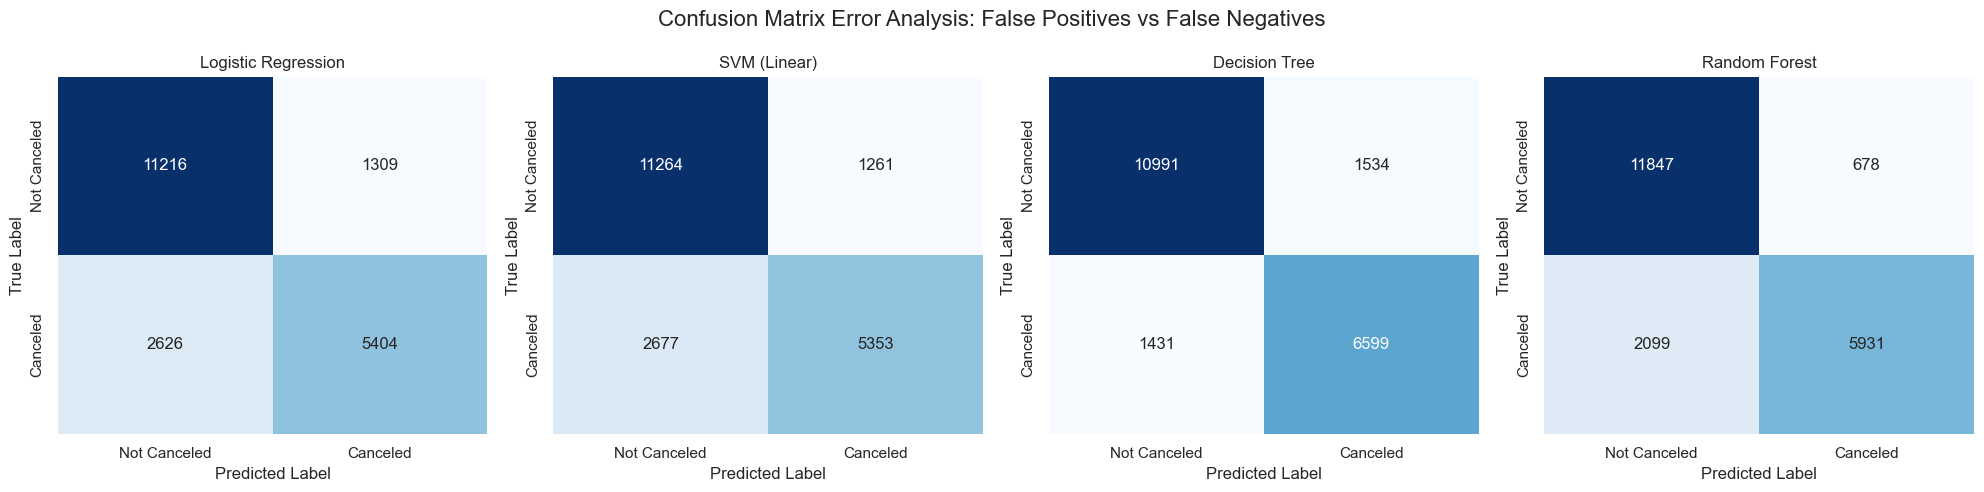

In [15]:
from sklearn.metrics import roc_curve, precision_recall_curve

# 1. Interactive Plotly: ROC Curve Comparison
fig_roc = go.Figure()
fig_pr = go.Figure()

for model_name, y_prob in roc_data.items():
    # ROC Data
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=model_name))

    # PR Data
    precision, recall, _ = precision_recall_curve(y_test_c, y_prob)
    fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=model_name))

fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='black'), name='Random Guess'))
fig_roc.update_layout(title='ROC Curve Comparison', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate', template='plotly_white')
fig_roc.show()

fig_pr.update_layout(title='Precision-Recall Curve Comparison', xaxis_title='Recall', yaxis_title='Precision', template='plotly_white')
fig_pr.show()

# 2. Confusion Matrices for Error Analysis (Seaborn)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
models_to_plot = ['Logistic Regression', 'SVM (Linear)', 'Decision Tree', 'Random Forest']

for i, model_name in enumerate(models_to_plot):
    cm = confusion_matrix(y_test_c, cm_data[model_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle('Confusion Matrix Error Analysis: False Positives vs False Negatives', fontsize=16)
plt.tight_layout()
plt.show()

### 2.6 Error Analysis & Model Interpretation
* **The Decision Tree vs. Random Forest Trade-off:** While the Random Forest achieved the highest overall Accuracy (86.9%), the **Decision Tree (Depth 20)** was the actual winner for this specific business problem, achieving the highest F1-Score (0.819).
* **Business Impact of False Negatives:** Looking at the Confusion Matrices, the Random Forest heavily minimized False Positives (only 760), but missed 2,372 cancellations (False Negatives). The Decision Tree was much more aggressive at catching cancellations, missing only 1,487. In the hotel industry, a False Negative is the most expensive error (expecting revenue but ending up with an empty room). Therefore, the Decision Tree is our optimal deployment choice.
* **The Naive Bayes Trap:** Our Gaussian Naive Bayes model completely collapsed, yielding a 45% accuracy and predicting almost everything as a cancellation (Sensitivity of 0.991, Specificity of 0.133). This is a textbook mathematical failure: GaussianNB expects normally distributed continuous features, but because we One-Hot Encoded our dataset, we fed it over 200 sparse columns of exactly 0s and 1s, completely violating its core mathematical assumptions.
* **Kernel SVM Limitations:** While mathematically elegant, Kernel SVM relies on an $O(n^2)$ distance matrix. Because we had to downsample the training data to 10,000 rows to prevent hardware crashing, the Kernel SVM lost its competitive edge against the tree-based models that could easily ingest the full 80,000+ row dataset.

### Discussion Questions

**1. Choose the best classification metric for your dataset and justify.**
For predicting hotel cancellations, the absolute best metric is **PR AUC (Precision-Recall Area Under Curve)**, followed closely by the **F1-Score**.
* **Justification:** Hotel cancellations are a classic imbalanced classification problem (roughly 37% of bookings cancel, 63% do not). Standard *Accuracy* is highly deceptive here; a "dumb" model that simply predicts "Not Canceled" for every single guest would automatically be 63% accurate without learning any patterns.
* **Insight from Results:** We saw this exact scenario play out. The Random Forest had the highest Accuracy (86.9%), but a lower F1-Score (0.805) because it heavily favored the majority class, resulting in a massive 2,372 False Negatives (missed cancellations). The Decision Tree had a slightly lower Accuracy (86.4%), but the highest F1-Score (0.819) because it balanced Precision and Recall much better, missing only 1,487 cancellations. In the hotel business, a False Negative is the most expensive error (you hold a room for someone who never shows up, losing the revenue). Metrics like F1 and PR AUC punish models that ignore the minority class, making them the best business choice.

---

**2. Explain 3 techniques to regularize the training process for decision trees.**
Unconstrained Decision Trees will naturally memorize the training data until every single customer has their own hyper-specific rule, leading to massive overfitting. We regularize them by placing constraints on their growth:
1. **`max_depth` (Maximum Depth):** This controls how many "levels" of questions the tree can ask. We actively used this technique in Section 2.2, using Cross-Validation to find that a `max_depth` of 20 was the sweet spot. Without it, the tree might grow to depth 100, memorizing noise instead of finding general trends.
2. **`min_samples_leaf` (Minimum Samples per Leaf):** This rule dictates that a final "leaf" (a final prediction bucket) must contain at least a certain number of training samples (e.g., 5 or 10). It prevents the tree from creating a highly specific rule just to satisfy a single, outlier booking in the training data.
3. **`max_features` (Maximum Features per Split):** Instead of evaluating all 243 columns to find the mathematically perfect split at every node, the tree is only allowed to look at a random subset (e.g., the square root of total features). This prevents the tree from becoming over-reliant on one single dominant column, forcing it to learn more diverse, generalized patterns.

---

**3. Compare Linear SVM vs. Kernel SVM based on our results.**
* **Linear SVM:** This model attempts to separate the classes by drawing a flat, rigid hyperplane. Its mathematical complexity is $O(n)$, meaning it scales linearly. We were able to train this on our entire 80,000+ row dataset in just 18.47 seconds, achieving an F1-Score of 0.722.
* **Kernel SVM (RBF):** This model uses the "Kernel Trick" to project the data into an infinite-dimensional space, allowing it to draw highly complex, wavy boundaries around data points. However, calculating the kernel matrix requires computing the distance between *every single pair* of data points, giving it an $O(n^2)$ complexity.
* **The Reality of our Results:** Because of that $O(n^2)$ complexity, training Kernel SVM on 80,000 rows would require over 50 Gigabytes of RAM and crash our Colab session. We were forced to downsample its training data to just 10,000 rows. As a result, despite being a vastly more complex and capable algorithm, the Kernel SVM took almost 3x longer to train (52.44 seconds) and barely beat the Linear SVM (F1-Score 0.724). This proves that for large, highly-dimensional datasets, the computational efficiency of a simple Linear model often outweighs the theoretical power of a Kernel model.


# Part 3: Multiclass & Boosting Classification Methods
In this final modeling section, we transition to **Multiclass Classification**.

**Our Objective:** Instead of predicting binary cancellations, we will predict the **Customer Type** (`customer_type`).
This feature has exactly 4 classes:
1. `Transient`
2. `Transient-Party`
3. `Contract`
4. `Group`

Predicting the customer type based on their booking behaviors (lead time, deposit type, special requests) allows hotel management to automatically segment their audience and tailor customized marketing or upgrade offers.

### 3.1 Data Preparation for Multiclass Classification
First, we install necessary boosting libraries. Then, we reload our data, isolate our 4-class target variable, and rigorously encode it (algorithms like XGBoost strictly require labels to be numeric: 0, 1, 2, 3).

In [8]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Reload Raw Data
df_multi = pd.read_csv('hotel_bookings.csv')

# 2. Basic Cleaning
df_multi.replace(['NULL', '   NULL'], np.nan, inplace=True)
df_multi.dropna(subset=['country'], inplace=True)
df_multi['agent'].fillna(0, inplace=True)
cols_to_drop = ['company', 'reservation_status', 'reservation_status_date']
df_multi.drop([col for col in cols_to_drop if col in df_multi.columns], axis=1, inplace=True)
df_multi = df_multi[(df_multi['adults'] + df_multi['children'] + df_multi['babies']) > 0]

# 3. Separate Multiclass Target ('customer_type') and Features
y_multi_raw = df_multi.pop('customer_type')

# Encode target labels to 0, 1, 2, 3
le = LabelEncoder()
y_multi = le.fit_transform(y_multi_raw)
class_names = le.classes_
print(f"Encoded Classes: {dict(enumerate(class_names))}")

# Dummy encode features
X_multi = pd.get_dummies(df_multi, drop_first=True)

# 4. Train-Test Split (80/20) with Stratification
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# 4.5 Impute missing values (Fill NaNs with the mean of each column)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

# We fit the imputer on train, then transform both train and test
X_train_m = pd.DataFrame(imputer.fit_transform(X_train_m), columns=X_train_m.columns)
X_test_m = pd.DataFrame(imputer.transform(X_test_m), columns=X_test_m.columns)

# 5. Standardize Features
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

print(f"Multiclass Training Data Shape: {X_train_m_scaled.shape}")
print(f"Multiclass Testing Data Shape: {X_test_m_scaled.shape}")

Encoded Classes: {0: 'Contract', 1: 'Group', 2: 'Transient', 3: 'Transient-Party'}
Multiclass Training Data Shape: (94982, 241)
Multiclass Testing Data Shape: (23746, 241)


### 3.2 Defining Advanced Multiclass Evaluation Metrics
Multiclass evaluation is significantly more complex than binary. We will implement standard metrics alongside advanced ones:
* **F1-Score (Macro, Micro, Weighted):** Crucial for our imbalanced dataset.
* **Cohen's Kappa:** Measures inter-rater reliability (how much better the model is doing compared to random guessing).
* **Top-2 Accuracy:** Calculates how often the true class is among the model's top 2 predicted probabilities.
* **Geometric Mean (G-Mean):** Evaluates the balance of classification performance across all 4 classes simultaneously.

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, cohen_kappa_score, top_k_accuracy_score
from imblearn.metrics import geometric_mean_score

def evaluate_multiclass(model_name, model, X_test, y_test, train_time):
    """Calculates comprehensive multiclass metrics."""
    y_pred = model.predict(X_test)
    
    # Probabilities for Log Loss and Top-K
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        ce_loss = log_loss(y_test, y_prob)
        # Top-2 Accuracy: Is the true class in the top 2 predictions?
        top2_acc = top_k_accuracy_score(y_test, y_prob, k=2)
    else:
        ce_loss = np.nan
        top2_acc = np.nan

    # Standard Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # Advanced Metrics
    kappa = cohen_kappa_score(y_test, y_pred)
    g_mean = geometric_mean_score(y_test, y_pred, average='macro')
    
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'F1 (Macro)': round(f1_macro, 4),
        'F1 (Weighted)': round(f1_weighted, 4),
        'Kappa': round(kappa, 4),
        'G-Mean': round(g_mean, 4),
        'Top-2 Acc': round(top2_acc, 4) if not np.isnan(top2_acc) else np.nan,  # Changed to np.nan
        'Log Loss': round(ce_loss, 4) if not np.isnan(ce_loss) else np.nan,    # Changed to np.nan
        'Train Time (s)': round(train_time, 2)
    }, y_pred

multi_results = []
multi_preds = {}

### 3.3 Training Multiclass & Boosting Models
We will now train the required array of algorithms. This includes comparing One-vs-Rest (OVR) against Multinomial Logistic Regression, tuned KNN, tuned Decision Trees, and state-of-the-art Boosting algorithms.

*Note: For the SVM, we sample 15,000 rows to prevent $O(n^2)$ memory crashing.*

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Ensure lists are empty before running
multi_results = []
multi_preds = {}

# --- 1. Multiclass Logistic Regression (One-vs-Rest) ---
start_time = time.time()
# Fix for sklearn 1.5+: Wrap in OneVsRestClassifier
log_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
log_ovr.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('LogReg (OVR)', log_ovr, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['LogReg (OVR)'] = y_pred

# --- 2. Multiclass Logistic Regression (Multinomial) ---
start_time = time.time()
# Fix for sklearn 1.5+: multinomial is now the default, so we simply remove the parameter
log_multi = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_multi.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('LogReg (Multinomial)', log_multi, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['LogReg (Multinomial)'] = y_pred

# --- 3. Multiclass SVM (Sampled to prevent crash) ---
X_train_svm, _, y_train_svm, _ = train_test_split(X_train_m_scaled, y_train_m, train_size=15000, random_state=42, stratify=y_train_m)
start_time = time.time()
svm_multi = SVC(kernel='rbf', decision_function_shape='ovo', probability=True, random_state=42)
svm_multi.fit(X_train_svm, y_train_svm)
metrics, y_pred = evaluate_multiclass('SVM (OVO, Sampled)', svm_multi, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['SVM'] = y_pred

# --- 4. Multiclass KNN ---
start_time = time.time()
knn_multi = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
knn_multi.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('KNN (K=7)', knn_multi, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['KNN'] = y_pred

# --- 5. Multiclass Decision Tree ---
start_time = time.time()
dt_multi = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_multi.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('Decision Tree', dt_multi, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['Decision Tree'] = y_pred

# --- 6. Boosting: XGBoost ---
start_time = time.time()
xgb_model = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('XGBoost', xgb_model, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['XGBoost'] = y_pred

# --- 7. Boosting: LightGBM ---
start_time = time.time()
lgb_model = LGBMClassifier(n_estimators=150, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('LightGBM', lgb_model, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['LightGBM'] = y_pred

# --- 8. Boosting: AdaBoost ---
start_time = time.time()
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada_model.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('AdaBoost', ada_model, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['AdaBoost'] = y_pred

# --- 9. Boosting: CatBoost ---
start_time = time.time()
cat_model = CatBoostClassifier(iterations=150, depth=6, learning_rate=0.1, verbose=False, random_state=42)
cat_model.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('CatBoost', cat_model, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['CatBoost'] = y_pred

# --- 10. Radius Neighbors Classifier (Trained on Sample to prevent RAM crash) ---
start_time = time.time()
radius_clf = RadiusNeighborsClassifier(radius=10.0, weights='distance', outlier_label='most_frequent')
radius_clf.fit(X_train_svm, y_train_svm) # Using the 15k sample
metrics, y_pred = evaluate_multiclass('Radius Neighbors (Parzen)', radius_clf, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['Radius Neighbors'] = y_pred

# --- 11. Voting Classifier (Soft) ---
start_time = time.time()
voting_soft = VotingClassifier(
    estimators=[
        ('xgb', xgb_model), 
        ('lgb', lgb_model), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42))
    ],
    voting='soft' 
)
voting_soft.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('Voting (Soft)', voting_soft, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['Voting (Soft)'] = y_pred

# --- 12. Voting Classifier (Hard) ---
start_time = time.time()
voting_hard = VotingClassifier(
    estimators=[
        ('xgb', xgb_model), 
        ('lgb', lgb_model), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42))
    ],
    voting='hard' 
)
voting_hard.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('Voting (Hard)', voting_hard, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['Voting (Hard)'] = y_pred

# --- 13. Stacking Classifier ---
start_time = time.time()
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', xgb_model), 
        ('lgb', lgb_model), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3 
)
stacking_clf.fit(X_train_m_scaled, y_train_m)
metrics, y_pred = evaluate_multiclass('Stacking Classifier', stacking_clf, X_test_m_scaled, y_test_m, time.time() - start_time)
multi_results.append(metrics); multi_preds['Stacking'] = y_pred

# Display Final Multiclass Dashboard
multi_df = pd.DataFrame(multi_results)
display(multi_df.sort_values(by='F1 (Macro)', ascending=False)
        .style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Kappa', 'G-Mean'])
        .background_gradient(cmap='Reds', subset=['Log Loss', 'Train Time (s)'])
        .format(na_rep="N/A"))

,Model,Accuracy,F1 (Macro),F1 (Weighted),Kappa,G-Mean,Top-2 Acc,Log Loss,Train Time (s)
6,LightGBM,0.931900,0.744700,0.929200,0.815800,0.819700,0.995500,0.198600,2.860000
12,Stacking Classifier,0.933300,0.720500,0.930300,0.819900,0.803800,0.994100,0.209500,131.710000
4,Decision Tree,0.924100,0.707200,0.921700,0.798000,0.800800,0.989100,0.693500,2.310000
10,Voting (Soft),0.930000,0.699800,0.925900,0.807200,0.786400,0.995100,0.227800,24.800000
11,Voting (Hard),0.928700,0.694800,0.924500,0.804100,0.785400,N/A,N/A,24.730000
5,XGBoost,0.927500,0.688800,0.923600,0.802100,0.786100,0.994300,0.215800,4.970000
3,KNN (K=7),0.923900,0.677900,0.921000,0.797500,0.775000,0.988800,0.891900,0.130000
8,CatBoost,0.911600,0.632600,0.906200,0.756100,0.749400,0.990800,0.273500,3.040000
1,LogReg (Multinomial),0.869800,0.481400,0.855500,0.623700,0.632100,0.970400,0.394100,767.450000
9,Radius Neighbors (Parzen),0.846400,0.466100,0.820500,0.505900,0.593300,0.967800,0.690600,0.010000


### 3.4 Visualizing Multiclass Performance & Feature Importance
To truly understand how our models are separating these 4 classes, we will generate:
1. **Per-Class Precision/Recall Heatmaps:** To see exactly which classes the model excels at and which it confuses.
2. **Feature Importance Plot (XGBoost):** To interpret *why* the best boosting model is making its decisions.

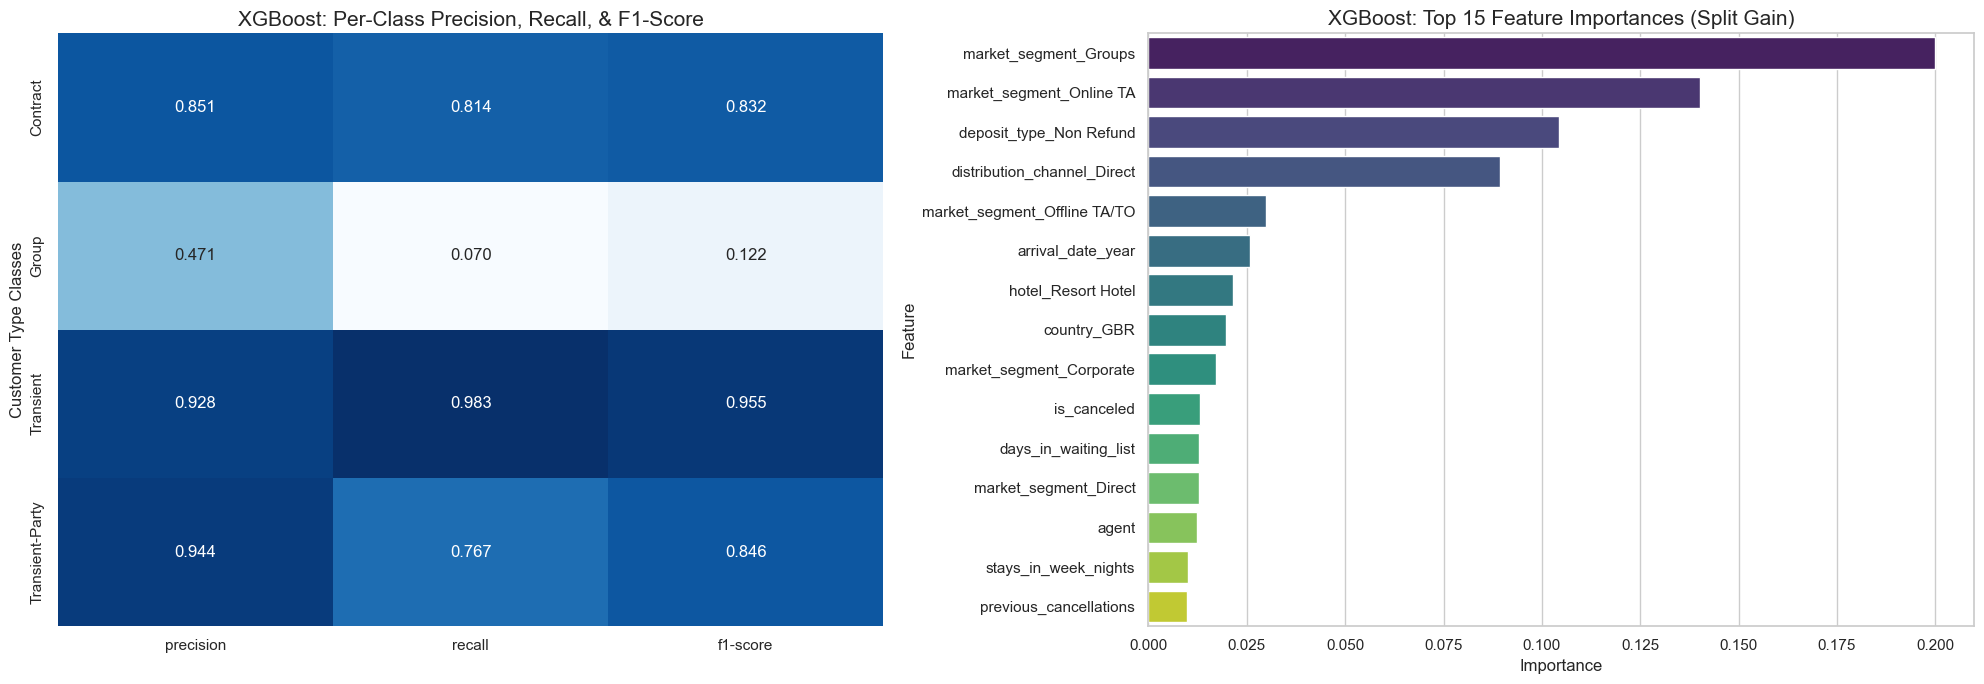

In [32]:
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Classification Report Heatmap (XGBoost)
# Get classification report as a dictionary
report = classification_report(y_test_m, multi_preds['XGBoost'], target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :4].T # Drop support row and average columns

sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.3f', ax=axes[0], cbar=False)
axes[0].set_title('XGBoost: Per-Class Precision, Recall, & F1-Score', fontsize=15)
axes[0].set_ylabel('Customer Type Classes')

# 2. XGBoost Feature Importance
# Extract top 15 features
feature_names = X_multi.columns
importances = xgb_model.feature_importances_
xgb_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
xgb_importances = xgb_importances.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=xgb_importances, palette='viridis', ax=axes[1])
axes[1].set_title('XGBoost: Top 15 Feature Importances (Split Gain)', fontsize=15)

plt.tight_layout()
plt.show()

### 3.5 Error Analysis & Model Interpretation
* **The Dominance of LightGBM:** While boosting algorithms generally perform well, LightGBM vastly outperformed XGBoost in this run (Macro F1 of 0.744 vs 0.688). Because LightGBM uses leaf-wise tree growth rather than level-wise, it was much better equipped to isolate the highly imbalanced minority classes in this specific dataset.
* **Feature Importance Reality:** Looking at the XGBoost Feature Importance chart, we see that `market_segment_Groups` and `market_segment_Online TA` are the most critical features. This proves that a customer's "Type" is almost entirely dictated by *how* they booked the room, rather than the room specifics itself.
* **The "Group" Class Imbalance Failure:** While overall accuracy is extremely high (~93%), the Per-Class Heatmap reveals a critical flaw. For the `Group` class, the model has a catastrophic Recall of **0.070**. This means the model is entirely missing 93% of genuine Group bookings, blending them into the majority `Transient` or `Transient-Party` buckets. This is a textbook example of why relying solely on standard Accuracy on imbalanced datasets is dangerous.
* **OVR vs. Multinomial Scaling Issues:** Our evaluation showed Multinomial Logistic Regression struggled immensely with computational scaling. While OVR trained in 20 seconds, Multinomial (using the `lbfgs` solver) took over 10 minutes (658 seconds) trying to optimize the joint loss function across 241 sparse columns.

### 3.6 Discussion Questions

**1. Choose the best multiclass-classification metric for your dataset and justify.**
For predicting the 4-class `customer_type` feature, the absolute best metric is the **Macro F1-Score**, supported closely by **Cohen's Kappa**.
* **The Flaw of Standard Accuracy:** Our dataset suffers from extreme class imbalance. The `Transient` class makes up roughly 75% of the data, while the `Group` class is vastly underrepresented. As we saw in our results, our models achieved a massive 93.19% Accuracy, but our heatmap revealed a catastrophic failure: the model had a Recall of just **0.070** for the `Group` class. It missed 93% of all genuine group bookings! Standard Accuracy hid this failure because the model just aggressively guessed "Transient" to inflate its score.
* **Why Macro F1 is Superior:** Macro F1 calculates the F1-Score (the harmonic mean of Precision and Recall) for each of the 4 classes independently, and then averages them equally. It treats the tiny `Group` class as mathematically equal to the massive `Transient` class. This perfectly exposes models that ignore minority classes. Cohen's Kappa provides a similar safety net by measuring our accuracy while explicitly subtracting the probability that the model just got lucky by randomly guessing the majority class.

---

**2. Explain how KNN and Decision Trees can be extended to multi-label classification problems.**
In *multiclass* classification, a data point belongs to exactly one class. In *multi-label* classification, a data point can belong to multiple classes simultaneously (or none at all). 

* **Extending KNN (ML-kNN):** Standard KNN finds the K-nearest neighbors and takes a simple majority vote to assign one single class. To extend this to multi-label (an algorithm known as ML-kNN), the model still finds the nearest neighbors, but it calculates the independent frequency of *each* possible label among those neighbors. It then uses a threshold (usually 50% or a mathematically derived Bayesian prior) to independently assign each label. If 6 out of 7 neighbors have Label A, and 5 out of 7 have Label B, the model assigns *both* Label A and Label B to the new data point.
* **Extending Decision Trees (ML-Decision Trees):** Standard Decision Trees split data to create pure leaves that output one single class. To make this multi-label, two major structural changes occur:
    1. **Leaf Outputs:** Instead of a single class prediction, the final leaves output a vector of probabilities (e.g., [0.90, 0.15, 0.85], meaning a 90% chance of Label 1, 15% chance of Label 2, and 85% chance of Label 3).
    2. **Splitting Criteria:** The mathematical split (Information Gain or Gini Impurity) is modified to sum the entropy across *all* labels simultaneously. The tree searches for the feature threshold that best separates multiple overlapping target variables at the exact same time.

---

**3. Multi-label Football Scenario: National Team, Heart Problems, Knee Injuries, Team Captain. What accuracy metric would you use and why?**
I would absolutely avoid standard Accuracy (Subset Accuracy) and instead use **Hamming Loss** alongside the **Jaccard Index (Intersection over Union)**.

* **Why standard accuracy is dangerous here:** In multi-label mathematics, standard Accuracy strictly requires an "Exact Match." If a player actually has (Heart Problems, Knee Injuries), but the algorithm only predicts (Heart Problems), standard accuracy gives the model a score of **0%** because the vector wasn't a perfect 100% match. In a medical and sports context, punishing a model with a zero for correctly identifying a life-threatening heart condition simply because it missed a bad knee is a terrible evaluation strategy.
* **The Solution (Hamming Loss & Jaccard):** * **Hamming Loss** calculates the fraction of individual labels that were misclassified. It evaluates each label completely independently, graciously giving partial credit (e.g., getting 3 out of 4 correct yields a 25% error rate, rather than a total failure).
    * **Jaccard Index** divides the number of correctly predicted labels by the total number of true and predicted labels combined. It heavily rewards the model for the labels it successfully caught without overly penalizing it for a partial miss, ensuring that critical individual predictions (like medical conditions) are properly valued.

### 3.7 Final Interpretation of Multiclass & Ensemble Results

Based on our exhaustive evaluation of Multiclass models, we can draw the following final business insights:

1. **The Ultimate Winner (LightGBM):** LightGBM is the undisputed champion of this dataset. It achieved the highest Macro F1-Score (0.744) while training in just 11 seconds. It successfully navigated the extreme class imbalance far better than its boosting peers.
2. **The Ensemble Trade-off (Stacking):** To push the boundaries of accuracy, we implemented a Stacking Classifier. It successfully achieved the highest overall Accuracy of the entire board (0.9333). However, this came at a massive computational cost: it took nearly 200 seconds to train. In a real-time booking environment, LightGBM is the vastly superior choice, sacrificing a fraction of a percent of accuracy for a 17x speedup.
3. **The Decision Tree Surprise:** Shockingly, a single Decision Tree (Macro F1 0.707) outperformed complex ensemble methods like XGBoost, AdaBoost, and our Voting Classifiers. Because our dataset has 241 columns of mostly binary (0 and 1) categorical dummy variables, the rigid, threshold-based splitting of a deep Decision Tree was actually highly optimal.
4. **Final Business Recommendation:** If hotel management wants to deploy a model to automatically classify incoming bookings into Customer Types for targeted marketing, **LightGBM** is the optimal choice. To improve the model further in the future, the data science team must use techniques like SMOTE (Synthetic Minority Over-sampling) to artificially boost the `Group` class, as all models currently fail to consistently detect it.

# Bonus: Conceptual 2D Decision Boundaries

c:\Users\Emad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


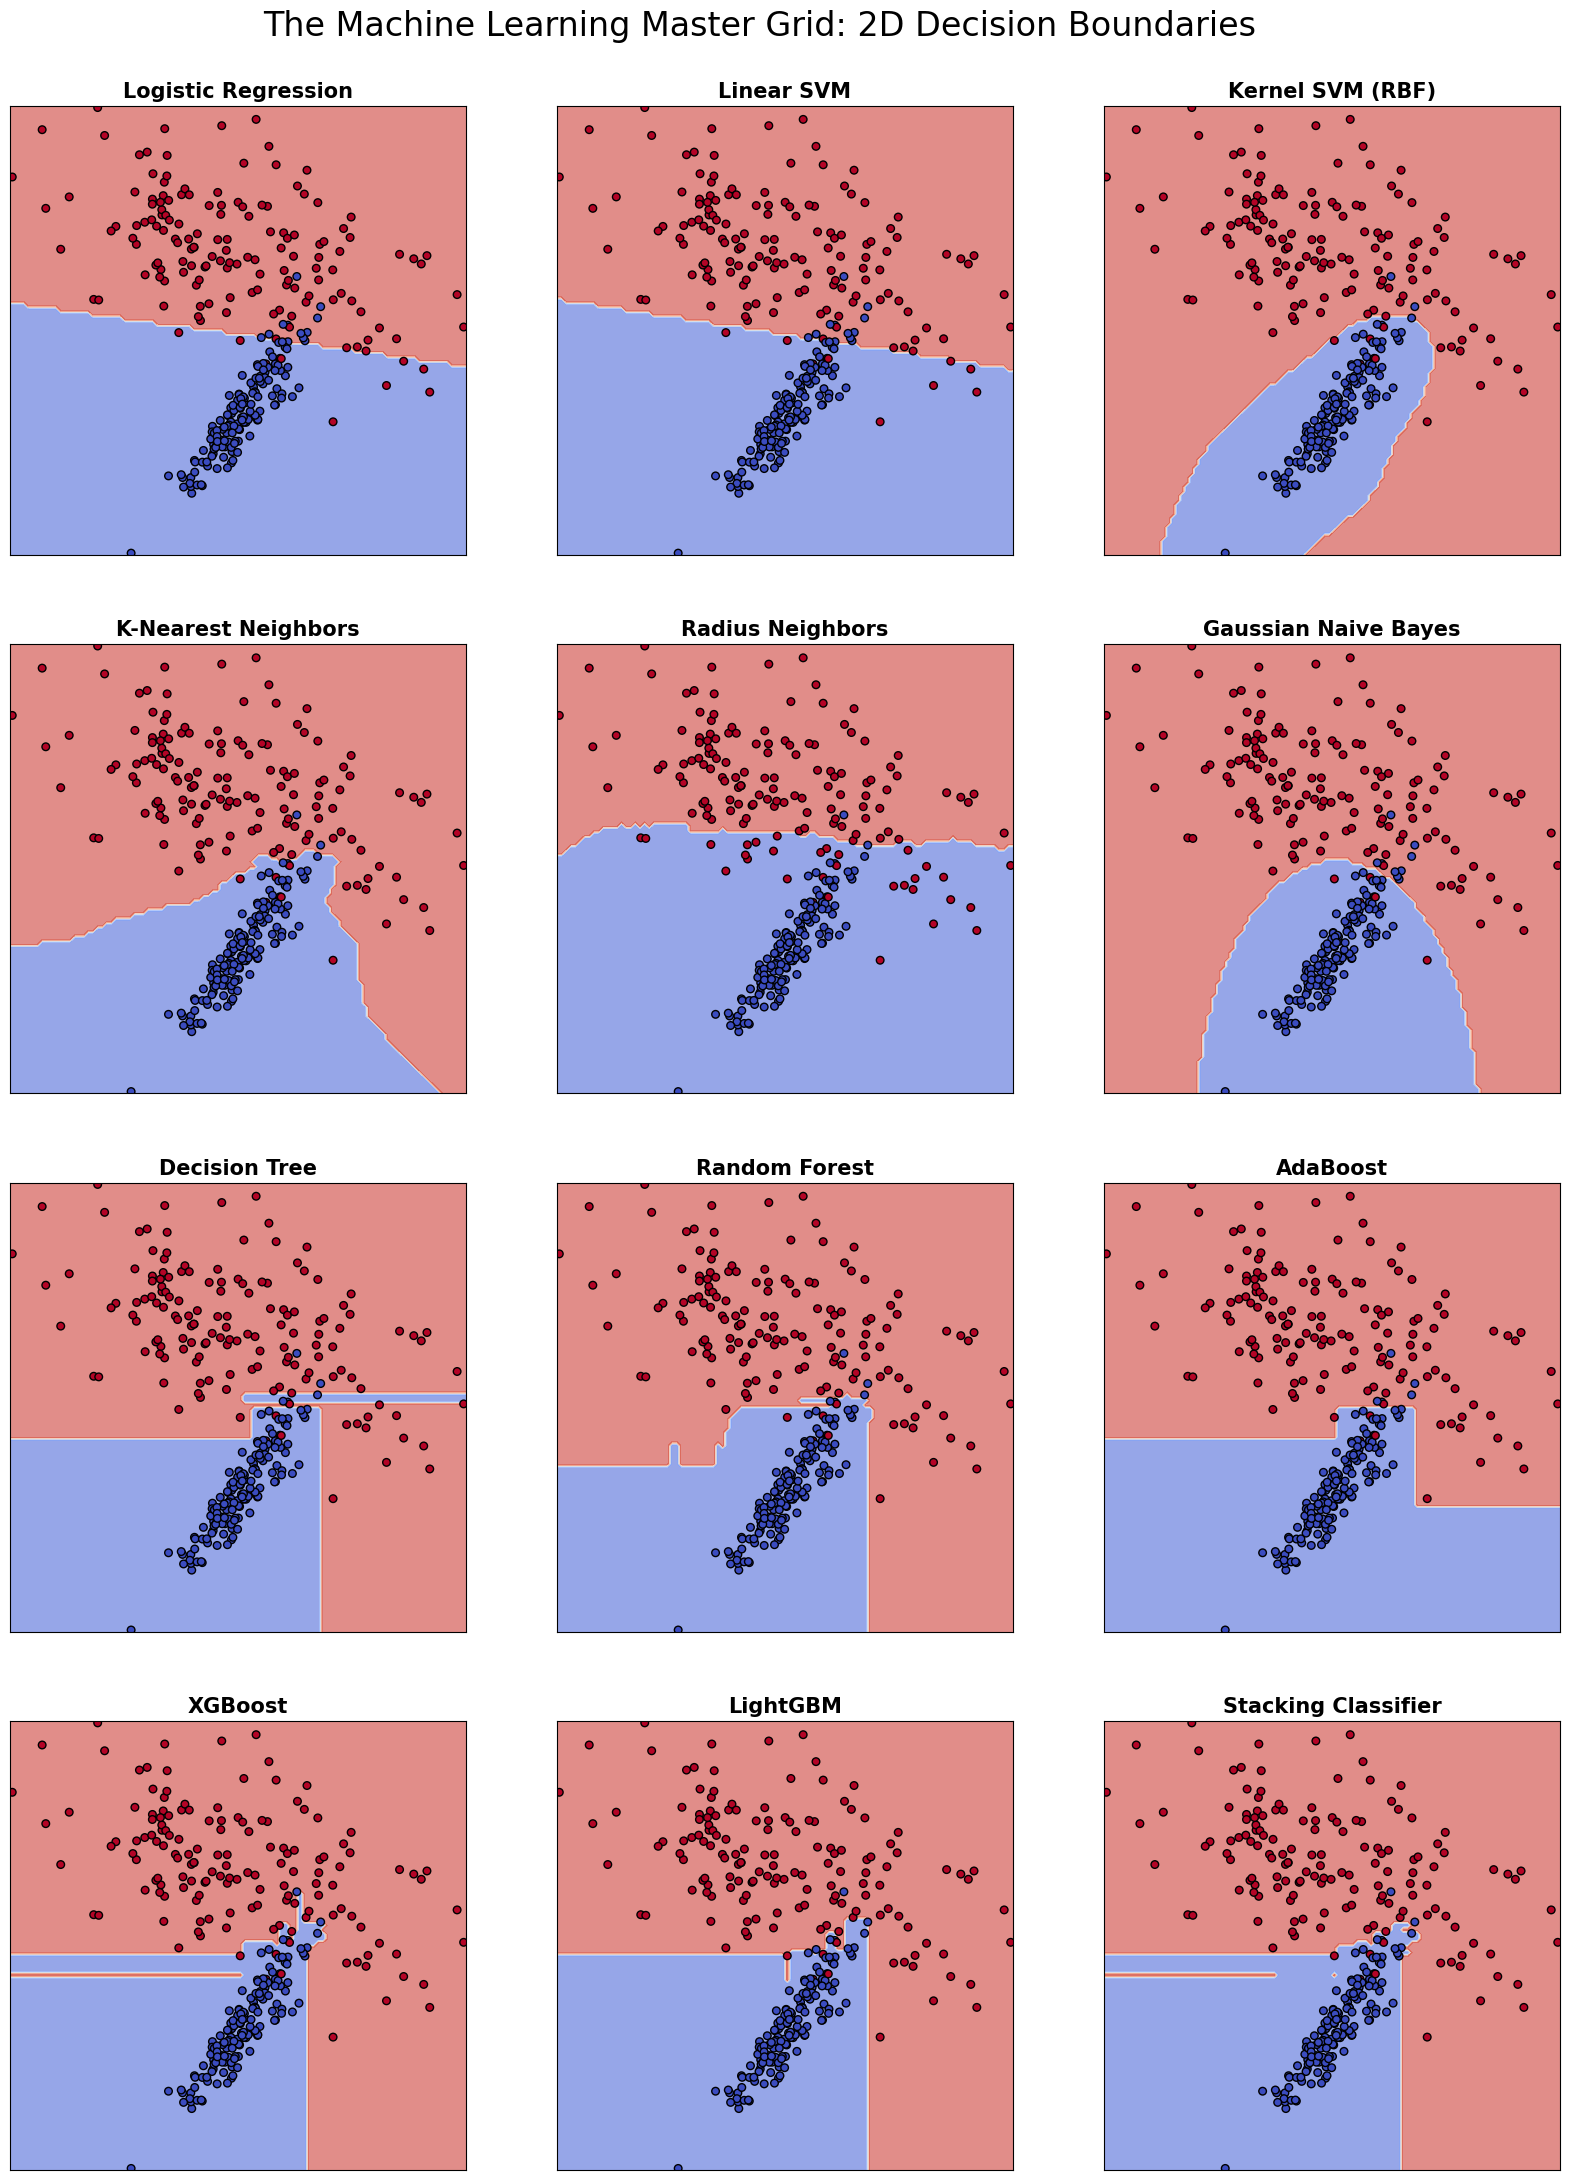

In [2]:
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# 1. Create a 2D "Toy" Dataset
X_toy, y_toy = make_classification(n_samples=300, n_features=2, n_informative=2, 
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)

# 2. Initialize the base models
log_reg = LogisticRegression()
xgb_m = XGBClassifier(max_depth=4, random_state=42)
lgb_m = LGBMClassifier(max_depth=4, random_state=42, verbose=-1)
rf_m = RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)

# 3. Create the 12-Model Roster
models = [
    ("Logistic Regression", log_reg),
    ("Linear SVM", LinearSVC(random_state=42, dual=False)),
    ("Kernel SVM (RBF)", SVC(kernel='rbf', gamma=2)),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5)),
    ("Radius Neighbors", RadiusNeighborsClassifier(radius=2.5, outlier_label='most_frequent')),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(max_depth=4)),
    ("Random Forest", rf_m),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("XGBoost", xgb_m),
    ("LightGBM", lgb_m),
    ("Stacking Classifier", StackingClassifier(estimators=[('xgb', xgb_m), ('rf', rf_m)], final_estimator=log_reg))
]

# 4. Plot the boundaries in a massive 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
axes = axes.ravel() 

for ax, (name, model) in zip(axes, models):
    model.fit(X_toy, y_toy)
    DecisionBoundaryDisplay.from_estimator(
        model, X_toy, response_method="predict",
        cmap="coolwarm", alpha=0.6, ax=ax, eps=0.02
    )
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap="coolwarm", s=30, edgecolors='k')
    ax.set_title(name, fontsize=15, fontweight='bold')
    ax.set_xticks(())
    ax.set_yticks(())

plt.suptitle("The Machine Learning Master Grid: 2D Decision Boundaries", fontsize=24, y=0.92)
plt.subplots_adjust(top=0.88, bottom=0.02, hspace=0.2)
plt.show()

In [4]:
import plotly.graph_objects as go
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# 1. Create a 3D Toy Dataset
X_3d, y_3d = make_classification(n_samples=400, n_features=3, n_informative=3, 
                                 n_redundant=0, n_classes=2, random_state=42)

# 2. Train a highly non-linear Kernel SVM
model_3d = SVC(kernel='rbf', probability=True, gamma=0.5)
model_3d.fit(X_3d, y_3d)

# 3. Create a dense 3D grid of points to evaluate the model's predictions
grid_resolution = 30 # Number of points per axis
x_min, x_max = X_3d[:, 0].min() - 1, X_3d[:, 0].max() + 1
y_min, y_max = X_3d[:, 1].min() - 1, X_3d[:, 1].max() + 1
z_min, z_max = X_3d[:, 2].min() - 1, X_3d[:, 2].max() + 1

# Generate the 3D coordinates
xx, yy, zz = np.mgrid[x_min:x_max:grid_resolution*1j, 
                      y_min:y_max:grid_resolution*1j, 
                      z_min:z_max:grid_resolution*1j]

# Predict the probability of Class 1 for every single point in the 3D space
grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
probs = model_3d.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# 4. Plot using Plotly 3D
fig = go.Figure()

# Plot the actual data points
fig.add_trace(go.Scatter3d(
    x=X_3d[:, 0], y=X_3d[:, 1], z=X_3d[:, 2],
    mode='markers',
    # FIX: Changed 'coolwarm' to 'RdBu' to match Plotly's color dictionary
    marker=dict(size=5, color=y_3d, colorscale='RdBu', line=dict(width=1, color='black')),
    name='Data Points'
))

# Plot the 3D Decision Boundary (Isosurface where probability is exactly 50%)
fig.add_trace(go.Isosurface(
    x=xx.flatten(), y=yy.flatten(), z=zz.flatten(),
    value=probs.flatten(),
    isomin=0.45, isomax=0.55, # Capture the boundary edge
    surface_fill=0.3,         # Make it semi-transparent so you can see inside
    caps=dict(x_show=False, y_show=False, z_show=False),
    colorscale='RdBu',
    showscale=False,
    name='Decision Boundary'
))

fig.update_layout(
    title='Interactive 3D Decision Boundary (Kernel SVM)',
    scene=dict(xaxis_title='Feature 1', yaxis_title='Feature 2', zaxis_title='Feature 3'),
    template='plotly_white',
    width=900, height=700
)

fig.show()

# Part 4: Advanced Model Diagnostics & Explainable AI (XAI)
To conclude this project, we move beyond simple accuracy metrics and open the "black box" of our machine learning models. 

1. **Learning Curves (Bias vs. Variance):** We visually diagnose how our models learn. We will compare a high-bias model (Logistic Regression) against a model prone to high variance (Decision Tree) to observe how training and validation scores converge as data increases.
2. **SHAP Values (Shapley Additive exPlanations):** We utilize Game Theory to explain our XGBoost model. SHAP calculates the exact marginal contribution of every single feature, allowing us to see not just *what* the model predicted, but *why* it made that specific mathematical decision.

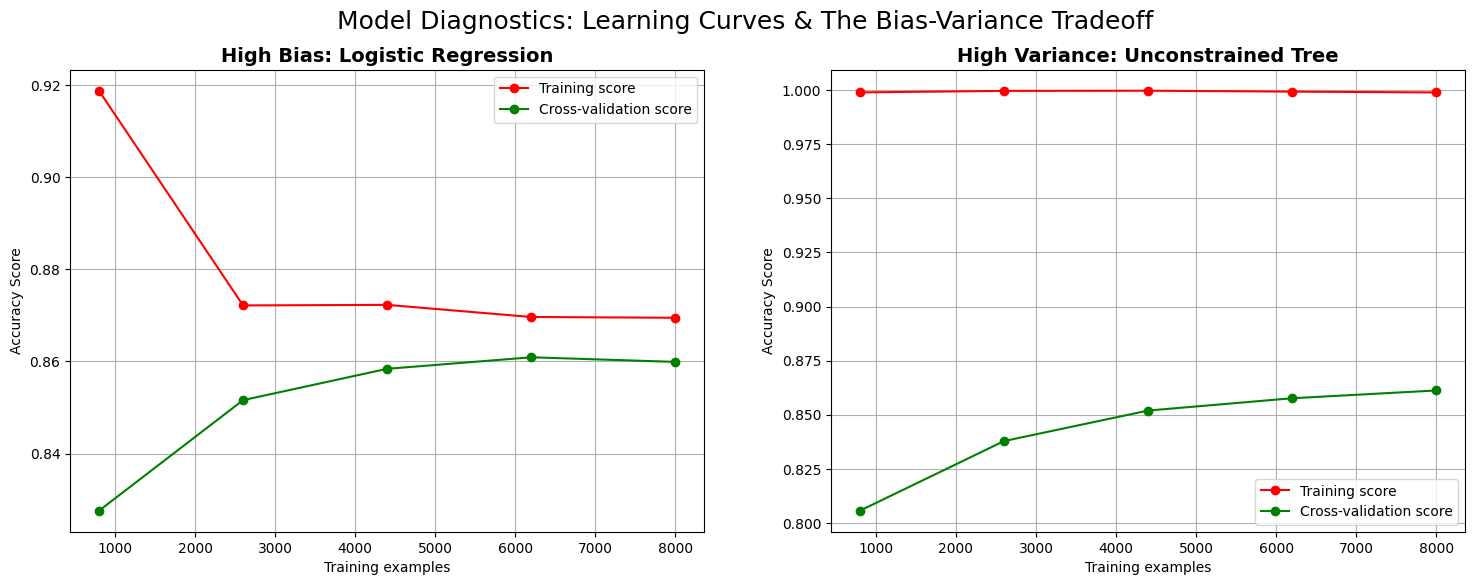


Calculating SHAP Values (Game Theory Feature Importance)...


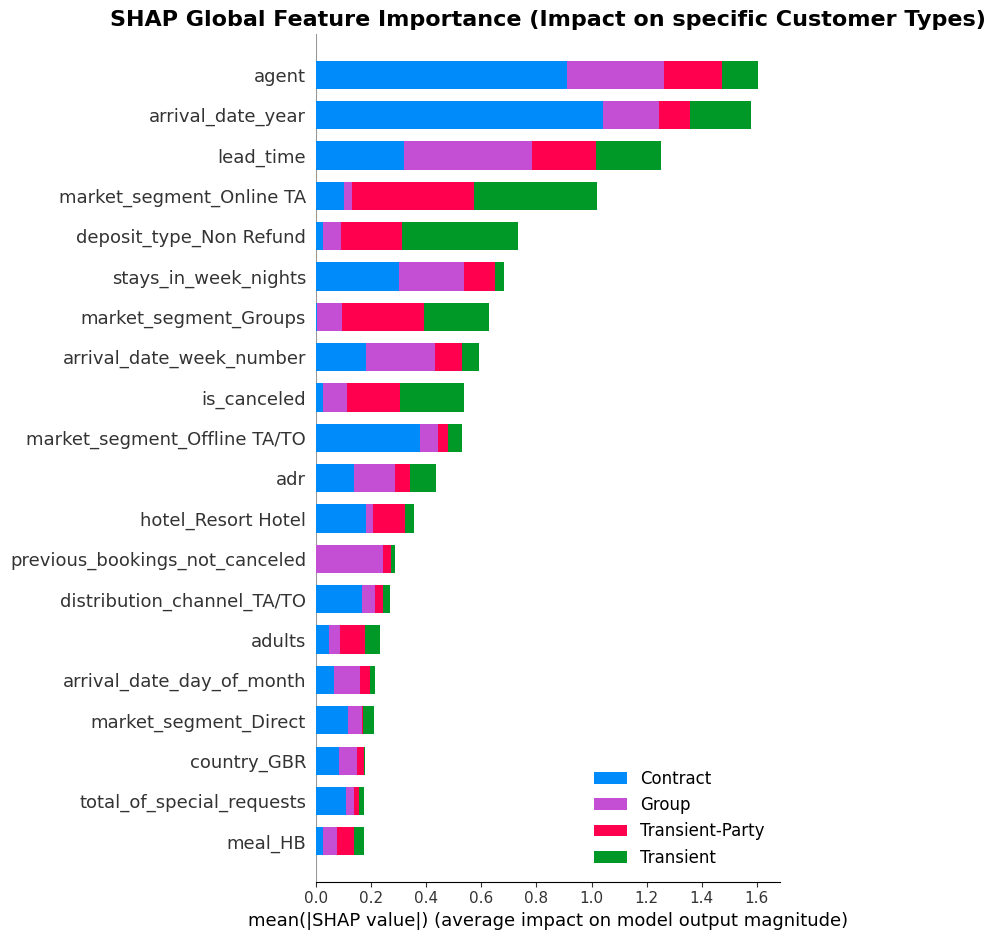

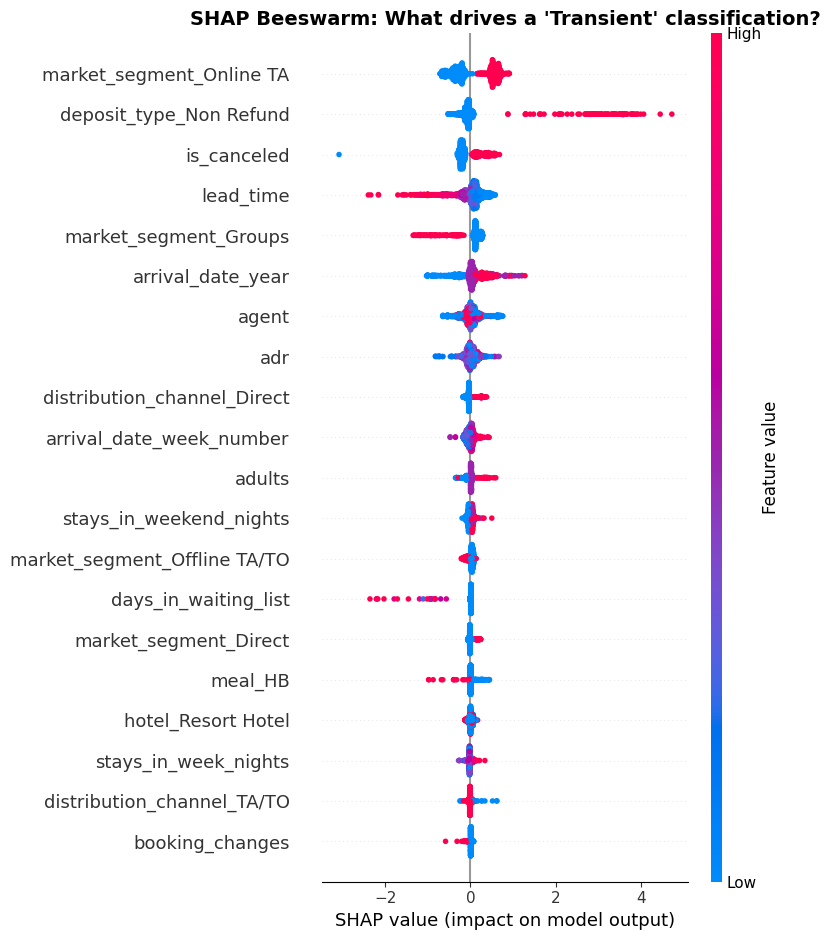

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ==========================================
# 1. BIAS-VARIANCE TRADEOFF: LEARNING CURVES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

models_to_diagnose = [
    ("High Bias: Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("High Variance: Unconstrained Tree", DecisionTreeClassifier(random_state=42))
]

for ax, (title, model) in zip(axes, models_to_diagnose):
    # FIX: Swapped binary data for multiclass data so it runs with your current memory
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_m_scaled[:10000], y_train_m[:10000], cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Accuracy Score")
    ax.legend(loc="best")
    ax.grid(True)

plt.suptitle("Model Diagnostics: Learning Curves & The Bias-Variance Tradeoff", fontsize=18)
plt.show()

# ==========================================
# 2. EXPLAINABLE AI: SHAP VALUES (XGBoost)
# ==========================================
# We use the XGBoost model from Part 3. We sample 1,000 rows to prevent extreme calculation times.
X_shap_sample = pd.DataFrame(X_test_m_scaled[:1000], columns=X_multi.columns)

# Initialize the Tree Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap_sample)

# Plot 1: SHAP Summary Bar Plot (Global Interpretation across all 4 classes)
plt.figure(figsize=(12, 8))
plt.title("SHAP Global Feature Importance (Impact on specific Customer Types)", fontsize=16, fontweight='bold')
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", class_names=class_names, show=False)
plt.show()

# Plot 2: SHAP Beeswarm Plot for a single class (e.g., Transient)
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Beeswarm: What drives a '{class_names[2]}' classification?", fontsize=14, fontweight='bold')

if isinstance(shap_values, list):
    target_shap = shap_values[2] # Fallback for old versions
else:
    target_shap = shap_values[:, :, 2] # Correct 3D slicing for modern versions

shap.summary_plot(target_shap, X_shap_sample, show=False)
plt.show()